# ToneFit ML — Google Colab Pipeline

**FaRL-64 Baseline vs Hierarchical FaRL-64 for Personal Color Season Classification**
Dataset: Deep Armocromia (Stacchio et al., ECCV 2024)

---

**Before running:**
1. Go to `Runtime → Change runtime type → T4 GPU`
2. Mount Google Drive (Step 1) — dataset must be uploaded to Drive first

**Pipeline:**
- **Step 6** — Train FaRL-64 Baseline (flat 2-FC head, season only)
- **Step 7** — Train Hierarchical FaRL-64 (novel contribution — season + sub-type)
- **Step 8** — Compare both models side by side

---
## Step 0 — Check GPU

In [1]:
import torch

if torch.cuda.is_available():
    print(f'✅ GPU available: {torch.cuda.get_device_name(0)}')
    print(f'   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('❌ No GPU detected!')
    print('Go to Runtime → Change runtime type → T4 GPU, then re-run.')

✅ GPU available: Tesla T4
   Memory: 15.6 GB


---
## Step 1 — Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted')

Mounted at /content/drive
✅ Google Drive mounted


---
## Step 2 — Clone Repo & Install Dependencies

In [ ]:
import os

REPO_URL = 'https://github.com/ajipal/ToneFit.git'
REPO_DIR = '/content/ToneFit'

if os.path.isdir(REPO_DIR):
    print('Repo already cloned. Fetching latest...')
    !cd {REPO_DIR} && git fetch origin && git checkout new-farl && git pull origin new-farl
else:
    !git clone -b new-farl {REPO_URL} {REPO_DIR}

os.chdir(REPO_DIR)
print(f'✅ Working directory: {os.getcwd()}')
!ls

In [ ]:
!pip install -q timm>=0.9.0 scikit-image imagehash
print('✅ Dependencies installed')

---
## Step 3 — Link Dataset from Google Drive

> Update DRIVE_DATASET_PATH to where you uploaded RGB-M in Google Drive.

In [6]:
import os

# ── UPDATE THIS PATH to where RGB-M is in your Google Drive ──
DRIVE_DATASET_PATH = '/content/drive/MyDrive/ToneFit/RGB-M'

# Create symlink so scripts can use RGB-M/ directly
LOCAL_LINK = '/content/ToneFit/RGB-M'
if not os.path.exists(LOCAL_LINK):
    os.symlink(DRIVE_DATASET_PATH, LOCAL_LINK)
    print(f'✅ Linked: {LOCAL_LINK} → {DRIVE_DATASET_PATH}')
else:
    print(f'✅ RGB-M already linked')

# Verify structure
print('\nDataset structure:')
for split in ['train', 'test']:
    split_path = os.path.join(LOCAL_LINK, split)
    if os.path.exists(split_path):
        seasons = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]
        total = 0
        print(f'  {split}/')
        for season in sorted(seasons):
            count = sum(len(files) for _, _, files in os.walk(os.path.join(split_path, season)))
            total += count
            print(f'    {season}/: {count} images')
        print(f'    TOTAL: {total} images')
    else:
        print(f'  ❌ {split}/ not found at {split_path}')

✅ Linked: /content/ToneFit/RGB-M → /content/drive/MyDrive/ToneFit/RGB-M

Dataset structure:
  train/
    autumn/: 1046 images
    spring/: 978 images
    summer/: 943 images
    winter/: 1041 images
    TOTAL: 4008 images
  test/
    autumn/: 259 images
    spring/: 203 images
    summer/: 186 images
    winter/: 264 images
    TOTAL: 912 images


---
## Step 4 — Preprocessing (EDA Features Only)

> Extracts CIELab/HSV features from training images for EDA visualization.
> Does NOT re-split the dataset — RGB-M/train/ and RGB-M/test/ are used as-is.

In [ ]:
import sys
if 'preprocess' in sys.modules:
    del sys.modules['preprocess']

import preprocess
preprocess.run()
print('✅ Preprocessing complete')

✅ Preprocessing complete


In [ ]:
# Verify features.csv was created
import pandas as pd
df = pd.read_csv('features.csv')
print(f'features.csv: {len(df)} rows')
print('\nClass distribution:')
print(df['season'].value_counts())
print('\nSample:')
df.head()

features.csv: 3719 rows

Class distribution:
season
summer    1056
spring    1014
autumn     858
winter     791
Name: count, dtype: int64

Sample:


,filename,season,label,split,L_mean,a_mean,b_mean,L_std,a_std,b_std,ITA,H_mean,S_mean,V_mean,skin_ratio,blur_score
0,train/autumn/deep/10306.png,autumn,0,train,41.720249,14.184730,18.478388,27.622932,9.886711,13.126000,-24.136079,0.080230,0.431447,0.527067,0.360703,946.876884
1,train/autumn/deep/10552.png,autumn,0,train,50.542500,13.861103,17.949295,24.667582,7.803957,9.339136,1.731181,0.057641,0.367073,0.613669,0.360703,252.488540
2,train/autumn/deep/11113.png,autumn,0,train,42.051094,14.148452,22.190800,30.172569,7.285640,12.278474,-19.707893,0.063950,0.598398,0.537362,0.360703,760.105386
3,train/autumn/deep/11174.png,autumn,0,train,41.095085,14.983027,19.159258,23.675959,7.593022,9.643398,-24.928246,0.056728,0.518485,0.522496,0.360703,1056.014194
4,train/autumn/deep/11199.png,autumn,0,train,51.811565,16.982109,27.802258,22.671562,7.075937,9.382059,3.728062,0.066956,0.557358,0.652398,0.360703,1187.431498


---
## Step 5 — EDA

/tmp/ipykernel_12053/2389427829.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data, labels=[s.capitalize() for s in SEASONS], patch_artist=True)


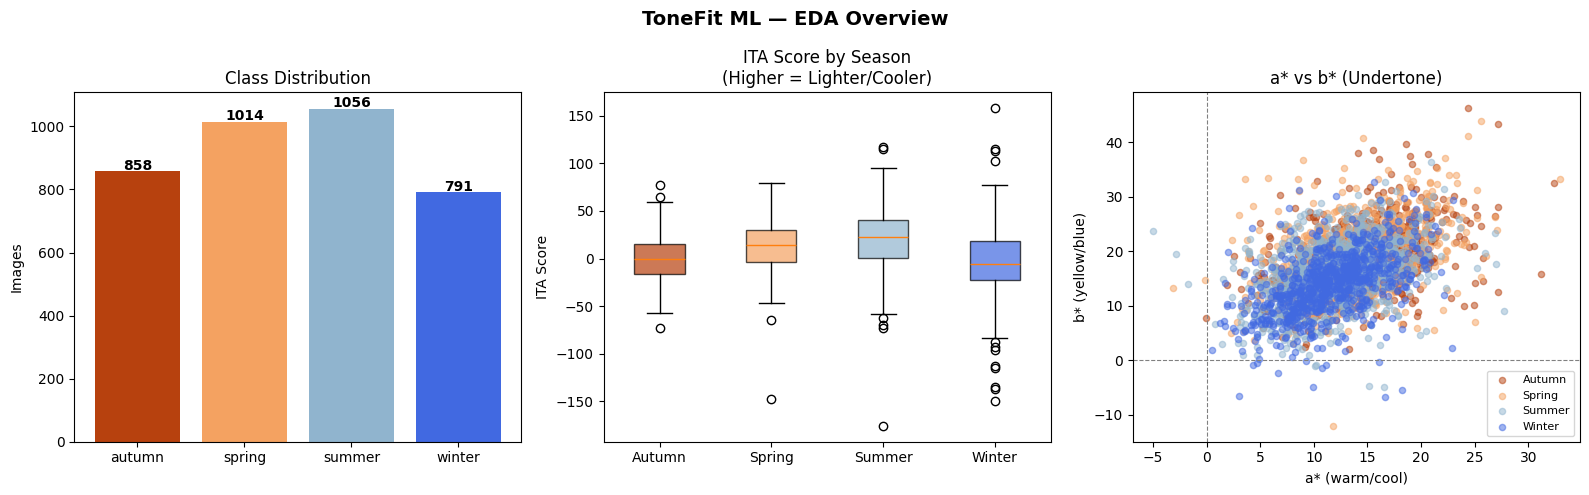

✅ EDA saved to results/eda_overview.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

os.makedirs('results', exist_ok=True)
df = pd.read_csv('features.csv')

SEASONS = ['autumn', 'spring', 'summer', 'winter']
COLORS  = {'autumn': '#B7410E', 'spring': '#F4A261', 'summer': '#90B4CE', 'winter': '#4169E1'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('ToneFit ML — EDA Overview', fontsize=14, fontweight='bold')

# Class distribution
counts = df['season'].value_counts()[SEASONS]
axes[0].bar(counts.index, counts.values, color=[COLORS[s] for s in counts.index])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Images')
for i, (s, v) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# ITA Score by season
data = [df[df['season'] == s]['ITA'].values for s in SEASONS]
bp = axes[1].boxplot(data, labels=[s.capitalize() for s in SEASONS], patch_artist=True)
for patch, s in zip(bp['boxes'], SEASONS):
    patch.set_facecolor(COLORS[s])
    patch.set_alpha(0.7)
axes[1].set_title('ITA Score by Season\n(Higher = Lighter/Cooler)')
axes[1].set_ylabel('ITA Score')

# a* vs b* scatter (undertone)
for s in SEASONS:
    sub = df[df['season'] == s]
    axes[2].scatter(sub['a_mean'], sub['b_mean'], label=s.capitalize(),
                    color=COLORS[s], alpha=0.5, s=20)
axes[2].axhline(0, color='gray', ls='--', lw=0.8)
axes[2].axvline(0, color='gray', ls='--', lw=0.8)
axes[2].set_title('a* vs b* (Undertone)')
axes[2].set_xlabel('a* (warm/cool)')
axes[2].set_ylabel('b* (yellow/blue)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('results/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA saved to results/eda_overview.png')

In [ ]:
# Pull updated code
!cd /content/ToneFit && git pull

# Install CLIP (required for FaRL)
!pip install git+https://github.com/openai/CLIP.git -q

# Clear cached module
import sys
if 'train_farl' in sys.modules:
    del sys.modules['train_farl']

print('✅ FaRL code updated - ready to retrain')

---
## Step 6 — Train FaRL-64 Baseline

> Trains the original flat 2-FC head on frozen FaRL-64 features (Season, 4-class).
> This is our **replication baseline** — targets Season acc > 0.554 (paper best).
>
> FaRL pretrained weights must be in `models/farl_weights.pth`.
> If weights not found, falls back to ResNeXt50 automatically.
>
> Expected training time: ~20–40 minutes on T4 GPU

In [ ]:
import os
os.makedirs('models', exist_ok=True)

!wget -q --show-progress -O models/farl_weights.pth \
  "https://github.com/FacePerceiver/FaRL/releases/download/pretrained_weights/FaRL-Base-Patch16-LAIONFace20M-ep64.pth"

print(f'✅ Done: {os.path.getsize("models/farl_weights.pth")/1e6:.0f} MB')

In [ ]:
import shutil
import os

# Save FaRL weights to Google Drive so you don't re-download next session
os.makedirs('/content/drive/MyDrive/ToneFit', exist_ok=True)

shutil.copy(
    'models/farl_weights.pth',
    '/content/drive/MyDrive/ToneFit/farl_weights.pth'
)

size = os.path.getsize('/content/drive/MyDrive/ToneFit/farl_weights.pth') / 1e6
print(f'✅ FaRL weights saved to Drive: {size:.0f} MB')
print('Next time — just copy from Drive instead of re-downloading')

In [ ]:
# Optional: copy FaRL weights from Drive
import shutil
os.makedirs('models', exist_ok=True)

FARL_WEIGHTS_DRIVE = '/content/drive/MyDrive/ToneFit/farl_weights.pth'
FARL_WEIGHTS_LOCAL = 'models/farl_weights.pth'

if os.path.exists(FARL_WEIGHTS_DRIVE) and not os.path.exists(FARL_WEIGHTS_LOCAL):
    shutil.copy(FARL_WEIGHTS_DRIVE, FARL_WEIGHTS_LOCAL)
    print(f'✅ FaRL weights copied from Drive')
elif os.path.exists(FARL_WEIGHTS_LOCAL):
    print(f'✅ FaRL weights already in models/')
else:
    print('⚠️  FaRL weights not found — will use ResNeXt50 fallback')

In [ ]:
# Check if training is actually using GPU
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Memory used: {torch.cuda.memory_allocated(0)/1e9:.2f} GB")
print(f"Memory cached: {torch.cuda.memory_reserved(0)/1e9:.2f} GB")

In [ ]:
if 'train_farl' in sys.modules:
    del sys.modules['train_farl']

import train_farl
train_farl.main()
print('✅ FaRL training complete')

In [ ]:
# Show FaRL training curves
from IPython.display import Image as IPImage, display
if os.path.exists('results/farl_training.png'):
    display(IPImage('results/farl_training.png'))
else:
    print('Training curves not found yet')

In [ ]:
import shutil, glob, os

# Save models to Drive
os.makedirs('/content/drive/MyDrive/ToneFit/Evaluation/models', exist_ok=True)
os.makedirs('/content/drive/MyDrive/ToneFit/Evaluation/results/FARL', exist_ok=True)

# Save FaRL model
shutil.copy('models/farl_model.pth',
            '/content/drive/MyDrive/ToneFit/Evaluation/models/farl_model.pth')

# Save all results
for f in glob.glob('results/*'):
    shutil.copy(f, '/content/drive/MyDrive/ToneFit/Evaluation/results/FARL/')

print('✅ All saved to Drive!')
print('You can now safely close Colab.')

---
## Step 7 — Train Hierarchical FaRL-64 (Novel Contribution)

> **Novel architecture:** frozen FaRL-64 backbone + two-stage hierarchical head.
> Stage 2 (Sub-Type) is conditioned on Stage 1 (Season) logits.
> Targets: Season acc > 0.554 (FaRL-64) AND Sub-Type acc > 0.318 (FaRL-16).
>
> Training saves a checkpoint every epoch.  If Colab crashes, re-run the
> "Check for resume checkpoint" cell and the training cell — it picks up
> exactly where it left off.
> Results are also synced to Drive every 5 epochs automatically.

In [ ]:
# Pull latest code and install pyyaml (needed for configs/hierarchical.yaml)
!cd /content/ToneFit && git fetch origin && git checkout new-farl && git pull origin new-farl
!pip install -q pyyaml
import os
os.makedirs('results', exist_ok=True)
os.makedirs('models',  exist_ok=True)

files = ['train.py', 'hierarchical_head.py',
         'evaluate_hierarchical.py',
         'configs/hierarchical.yaml']
for f in files:
    exists = os.path.exists(f)
    print(f"{'✅' if exists else '❌'} {f}")
print('Setup complete')

In [ ]:
import os, shutil

DRIVE_FARL  = '/content/drive/MyDrive/ToneFit/models/farl_model.pth'
LOCAL_FARL  = 'farl_model.pth'

if not os.path.exists(LOCAL_FARL):
    if os.path.exists(DRIVE_FARL):
        shutil.copy(DRIVE_FARL, LOCAL_FARL)
        size = os.path.getsize(LOCAL_FARL) / 1e6
        print(f'Copied farl_model.pth from Drive ({size:.0f} MB)')
    else:
        print('WARNING: farl_model.pth not found in Drive or local.')
        print('Training will start from random ViT-B/16 weights (still valid).')
else:
    size = os.path.getsize(LOCAL_FARL) / 1e6
    print(f'farl_model.pth already present ({size:.0f} MB)')

In [ ]:
import glob, os, re

RESULTS_DIR = 'results'
DRIVE_CKPT_DIR = '/content/drive/MyDrive/ToneFit/results'

# If results/ is empty, try to restore checkpoints from Drive first
local_ckpts = glob.glob(f'{RESULTS_DIR}/checkpoint_epoch_*.pth')
if not local_ckpts and os.path.isdir(DRIVE_CKPT_DIR):
    drive_ckpts = glob.glob(f'{DRIVE_CKPT_DIR}/checkpoint_epoch_*.pth')
    if drive_ckpts:
        print(f'Restoring {len(drive_ckpts)} checkpoint(s) from Drive...')
        for f in drive_ckpts:
            shutil.copy(f, RESULTS_DIR)
        # Also restore best checkpoint and history if present
        for fname in ('best_hierarchical.pth', 'hierarchical_history.json'):
            src = os.path.join(DRIVE_CKPT_DIR, fname)
            if os.path.exists(src):
                shutil.copy(src, RESULTS_DIR)
        local_ckpts = glob.glob(f'{RESULTS_DIR}/checkpoint_epoch_*.pth')

# Find the highest epoch checkpoint
def epoch_num(path):
    m = re.search(r'checkpoint_epoch_(\d+)\.pth', path)
    return int(m.group(1)) if m else -1

resume_arg = ''
if local_ckpts:
    latest = max(local_ckpts, key=epoch_num)
    ep = epoch_num(latest)
    resume_arg = f'--resume {latest}'
    print(f'Found checkpoint at epoch {ep}. Will resume from: {latest}')
else:
    print('No checkpoint found. Starting fresh training.')

print(f'\nresume_arg = {resume_arg!r}')

In [ ]:
import subprocess, sys

DRIVE_RESULTS = '/content/drive/MyDrive/ToneFit/results'
CONFIG        = 'configs/hierarchical.yaml'

cmd = (
    f'{sys.executable} train.py '
    f'--config {CONFIG} '
    f'--drive_dir {DRIVE_RESULTS} '
    f'{resume_arg}'
).strip()

print('Running:', cmd)
print('=' * 65)

# Run with live output
proc = subprocess.Popen(cmd.split(), stdout=subprocess.PIPE,
                        stderr=subprocess.STDOUT, text=True)
for line in proc.stdout:
    print(line, end='', flush=True)
proc.wait()

if proc.returncode == 0:
    print('\nTraining complete.')
else:
    print(f'\nProcess exited with code {proc.returncode}')

In [ ]:
import json, os
from IPython.display import Image as IPImage, display

# Print best result from history
hist_path = 'results/hierarchical_history.json'
if os.path.exists(hist_path):
    history = json.load(open(hist_path))
    best = max(history, key=lambda r: r.get('val_season_acc', 0))
    print(f"Best epoch : {best['epoch']}")
    print(f"Season acc : {best['val_season_acc']:.4f}  (target > 0.554)")
    print(f"Subtype acc: {best['val_subtype_acc']:.4f}  (target > 0.318)")
    beat_s   = best['val_season_acc']  > 0.554
    beat_sub = best['val_subtype_acc'] > 0.318
    print(f"Beat FaRL-64 season?    {'YES' if beat_s   else 'not yet'}")
    print(f"Beat FaRL-16 sub-type?  {'YES' if beat_sub else 'not yet'}")
else:
    print('No history file yet.')

---
## Step 8 — Compare FaRL-64 Baseline vs Hierarchical FaRL-64

> Runs both evaluation scripts and displays a side-by-side comparison.
> Run AFTER both Step 6 and Step 7 are complete.

In [ ]:
import subprocess, sys, os

# Evaluate FaRL-64 baseline (season, 4-class)
if os.path.exists('models/farl_model.pth'):
    print('--- Evaluating FaRL-64 Baseline ---')
    subprocess.run([sys.executable, 'evaluate_baseline.py'], check=False)
else:
    print('WARNING: models/farl_model.pth not found — skipping baseline eval.')

# Evaluate hierarchical model (season + sub-type)
if os.path.exists('results/best_hierarchical.pth'):
    print('\n--- Evaluating Hierarchical FaRL-64 ---')
    subprocess.run([sys.executable, 'evaluate_hierarchical.py',
                    '--checkpoint', 'results/best_hierarchical.pth'], check=False)
else:
    print('WARNING: results/best_hierarchical.pth not found — skipping hierarchical eval.')

In [ ]:
import json, os
import pandas as pd

rows = []

# FaRL-64 baseline results
csv_path = 'results/baseline_results.csv'
if os.path.exists(csv_path):
    df_base = pd.read_csv(csv_path)
    b = df_base[df_base['Model'] == 'FaRL-64 Baseline']
    if not b.empty:
        rows.append({
            'Model':             'FaRL-64 Baseline',
            'Season Acc':        b['Accuracy'].values[0],
            'Top-2 Acc':         b['Top-2 Accuracy'].values[0],
            'F1 (macro)':        b.get('F1 (macro)', pd.Series([None])).values[0],
            'Precision (macro)': b.get('Precision (macro)', pd.Series([None])).values[0],
            'Recall (macro)':    b.get('Recall (macro)', pd.Series([None])).values[0],
            'SubType Acc':       'N/A',
            'Top-3 Acc':         'N/A',
        })

# Hierarchical model results
hm_path = 'results/hierarchical_metrics.json'
if os.path.exists(hm_path):
    hm = json.load(open(hm_path))
    rows.append({
        'Model':             'Hierarchical FaRL-64',
        'Season Acc':        hm['season']['accuracy'],
        'Top-2 Acc':         hm['season']['top2_acc'],
        'F1 (macro)':        hm['season']['f1'],
        'Precision (macro)': hm['season']['precision'],
        'Recall (macro)':    hm['season']['recall'],
        'SubType Acc':       hm['subtype']['accuracy'],
        'Top-3 Acc':         hm['subtype']['top3_acc'],
    })

# Paper baselines
rows += [
    {'Model': 'FaRL-64 (paper)',  'Season Acc': 0.554, 'Top-2 Acc': 0.808, 'F1 (macro)': 0.548, 'SubType Acc': '—'},
    {'Model': 'FaRL-16 (paper)',  'Season Acc': 0.525, 'Top-2 Acc': 0.815, 'F1 (macro)': 0.516, 'SubType Acc': 0.318},
]

df = pd.DataFrame(rows)
print('\n===== Model Comparison =====')
print(df.to_string(index=False))

# Beat targets?
if len(rows) >= 2:
    h = next((r for r in rows if r['Model'] == 'Hierarchical FaRL-64'), None)
    if h:
        print(f"\nBeat FaRL-64 Season (> 0.554)?   {'YES' if float(h['Season Acc']) > 0.554 else 'Not yet'}")
        sub = h['SubType Acc']
        if sub != 'N/A' and sub != '—':
            print(f"Beat FaRL-16 SubType (> 0.318)?  {'YES' if float(sub) > 0.318 else 'Not yet'}")

In [ ]:
from IPython.display import Image as IPImage, display
import os

imgs = [
    ('results/confusion_baseline.png',            'FaRL-64 Baseline — Season'),
    ('results/confusion_season_hierarchical.png',  'Hierarchical — Season'),
    ('results/confusion_subtype_hierarchical.png', 'Hierarchical — Sub-Type'),
    ('results/baseline_comparison.png',            'Baseline vs Paper'),
]
for path, title in imgs:
    if os.path.exists(path):
        print(f'\n{title}:')
        display(IPImage(path))
    else:
        print(f'  (not found: {path})')

---
## Step 9 — Save Results to Drive

In [ ]:
import shutil, glob, os

DRIVE_RESULTS = '/content/drive/MyDrive/ToneFit/results'
DRIVE_MODELS  = '/content/drive/MyDrive/ToneFit/models'
os.makedirs(DRIVE_RESULTS, exist_ok=True)
os.makedirs(DRIVE_MODELS,  exist_ok=True)

for f in glob.glob('results/*'):
    shutil.copy(f, DRIVE_RESULTS)
print(f'Results saved to Drive: {DRIVE_RESULTS}')

for f in glob.glob('models/*.pth'):
    shutil.copy(f, DRIVE_MODELS)
if os.path.exists('farl_model.pth'):
    shutil.copy('farl_model.pth', DRIVE_MODELS)
print(f'Models saved to Drive: {DRIVE_MODELS}')

if os.path.exists('features.csv'):
    shutil.copy('features.csv', '/content/drive/MyDrive/ToneFit/features.csv')
    print('features.csv saved to Drive')

In [ ]:
import zipfile, glob, os
from google.colab import files

zip_path = 'ToneFit_results.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for f in glob.glob('results/*'):
        z.write(f)
    for f in glob.glob('models/*.pth'):
        z.write(f)
    if os.path.exists('farl_model.pth'):
        z.write('farl_model.pth')
    if os.path.exists('features.csv'):
        z.write('features.csv')

size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f'Created: {zip_path} ({size_mb:.1f} MB)')
files.download(zip_path)